# RL Post-Training — 0d : le reward model à la sauce SOTA (`trl.RewardTrainer`)

**Série RL Post-Training** (`rlpt_*`). Le [rlpt_0](rlpt_0_reward_model_from_scratch.ipynb) a écrit l'entraînement d'un reward model **à la main** : encodage des paires, boucle Adam, perte Bradley-Terry, métriques held-out. Ce notebook pose la question inverse : **que rapporte l'implémentation industrielle de référence** — `trl.RewardTrainer` (HuggingFace TRL) — *sur exactement le même problème* ?

- même monde synthétique, même juge Bradley-Terry, mêmes seeds `[0, 1, 7, 42]` ;
- **même architecture** (embedding + position + pooling + tête scalaire, **5 441 paramètres**), simplement encapsulée dans le contrat `PreTrainedModel` que `trl` exige ;
- mêmes métriques : accuracy paires, Brier, Spearman $\hat r$ vs $r^*$, bornes de Bayes.

La comparaison isole ainsi **une seule variable : le harnais** (`Trainer` + `RewardTrainer` vs boucle maison). Ce n'est pas un benchmark d'architecture : c'est la mesure de ce que l'on gagne — et de ce que l'on cesse de voir — quand on passe au SOTA. Quatre exigences de contrat, découvertes en chemin, sont documentées en §3 : elles font partie du prix.

## 1. Le même monde, verbatim

Monde repris du rlpt_0 sans rien changer : vocabulaire de 8 tokens de contenu `a`..`h`, deux prompts `<pA>`/`<pB>`, oracle graduée (poids de tokens + bonus positionnels conditionnés au prompt), juge **stochastique** Bradley-Terry ($P(a) = \sigma(r^*_a - r^*_b)$). Les bornes de Bayes ne dépendent que de ce monde — ce sont les mêmes colonnes de référence qu'en A.1.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
SEEDS = [0, 1, 7, 42]          # multi-seed (convention pr-review C)
LEN_R = 8                      # longueur de la reponse (comme rlpt_1)
TOK = ['<pA>', '<pB>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
V = {c: i for i, c in enumerate(TOK)}
DEV = 'cpu'

W_TOK = {'a': 0.30, 'b': 0.05, 'c': 0.10, 'd': 0.15,
         'e': 0.25, 'f': -0.10, 'g': -0.15, 'h': -0.20}


def true_reward(seq, prompt):
    """Oracle graduate : somme des poids de tokens + bonus positionnel conditionne au prompt."""
    r = sum(W_TOK[TOK[t]] for t in seq)
    if prompt == 0 and seq[0] == V['a']:
        r += 0.8
    if prompt == 1 and seq[4] == V['e']:
        r += 0.8
    return r


def seq_str(seq):
    return ' '.join(TOK[i] for i in seq)


import trl, transformers, datasets
print(f"torch {torch.__version__} | trl {trl.__version__} | transformers {transformers.__version__} | datasets {datasets.__version__}")


torch 2.13.0+cpu | trl 1.10.0 | transformers 5.12.1 | datasets 5.0.0


In [2]:
def sample_response(rng):
    """Reponse uniforme sur les tokens de contenu 'a'..'h' (politique aleatoire)."""
    return rng.integers(2, len(TOK), size=LEN_R)


def make_pairs(n_pairs, rng, min_gap=0.3, beta=1.0):
    """Paires (a, b) au meme prompt + etiquettes BT vraies.
    y = 1 : le juge a choisi 'a' ; y = 0 : il a choisi 'b'."""
    pw, y, rs, pr = [], [], [], []
    while len(pw) < n_pairs:
        prompt = int(rng.integers(0, 2))
        a, b = sample_response(rng), sample_response(rng)
        ra, rb = true_reward(a, prompt), true_reward(b, prompt)
        if abs(ra - rb) < min_gap:
            continue                      # paire quasi ex aequo : pas de signal
        p_a = 1.0 / (1.0 + np.exp(-beta * (ra - rb)))
        pw.append((a, b))
        y.append(1 if rng.random() < p_a else 0)
        rs.append((ra, rb))
        pr.append(prompt)
    return pw, np.array(y), np.array(rs), np.array(pr)


def bayes_bounds(rs_test, y_test):
    """Plafond d'accuracy et plancher de Brier, depuis le reward vrai (comme rlpt_0)."""
    d = rs_test[:, 0] - rs_test[:, 1]
    p = 1.0 / (1.0 + np.exp(-d))
    return float(np.mean(np.maximum(p, 1 - p))), float(np.mean(np.minimum(p**2, (1 - p)**2)))


rng0 = np.random.default_rng(0)
te0, y_test0, rs_test0, pr_test0 = make_pairs(1000, rng0)
acc_bayes, brier_bayes = bayes_bounds(rs_test0, y_test0)
print(f"bornes de Bayes (seed 0, test) : accuracy <= {acc_bayes:.3f} | Brier >= {brier_bayes:.4f}")
print("(rlpt_0, meme monde, seed 0 : accuracy <= 0.697 | Brier >= 0.0993)")


bornes de Bayes (seed 0, test) : accuracy <= 0.696 | Brier >= 0.1002
(rlpt_0, meme monde, seed 0 : accuracy <= 0.697 | Brier >= 0.0993)


## 2. Le contrat de données : `chosen_ids` / `rejected_ids`

`trl.RewardTrainer` ne connaît **ni** l'orientation par label `y`, **ni** nos séquences de tokens. Deux traductions sont nécessaires :

1. **L'orientation** : le label disparaît au profit de deux colonnes, `chosen` et `rejected`. `y = 1` → `chosen = a` ; `y = 0` → on échange. Le `Trainer` ne verra jamais `y`.
2. **La forme** : le collator par défaut **concatène** `chosen` puis `rejected` en un lot de $2N$ lignes, puis `compute_loss` refait `torch.chunk(logits, 2)` pour récupérer les deux moitiés. Cette convention est vérifiable dans le source de `trl` (lu ci-dessous) — et c'est elle qui impose la taille de lot réelle : un `per_device_train_batch_size` de 256 signifie **512 séquences** par pas.

Puisqu'on fournit des identifiants déjà calculés (`chosen_ids`/`rejected_ids`), `_prepare_dataset` **saute entièrement la tokenisation** — c'est un point d'entrée documenté, pas un contournement.

In [3]:
def to_chosen_rejected(pair_list, y, prompt_list):
    """Paires (a, b) + labels -> deux listes de sequences (prompt + reponse), orientees par le juge."""
    ch, rj = [], []
    for (a, b), yi, p in zip(pair_list, y, prompt_list):
        wa, wb = [p] + list(a), [p] + list(b)
        if yi == 1:
            ch.append(wa); rj.append(wb)
        else:
            ch.append(wb); rj.append(wa)
    return ch, rj


def to_dataset(pair_list, y, prompt_list):
    """-> datasets.Dataset pre-tokenise (chosen_ids/rejected_ids), contrat trl."""
    ch, rj = to_chosen_rejected(pair_list, y, prompt_list)
    return datasets.Dataset.from_dict({'chosen_ids': ch, 'rejected_ids': rj})


te_pairs, y_test, rs_test, pr_test = te0, y_test0, rs_test0, pr_test0
ds_demo = to_dataset(te_pairs, y_test, pr_test)
print("colonnes du dataset :", ds_demo.column_names)
print(f"exemple 0 (label y = {y_test[0]}) :")
ch0, rj0 = to_chosen_rejected([te_pairs[0]], y_test[:1], pr_test[:1])
print(f"  chosen   : [{TOK[ch0[0][0]]}] {seq_str(ch0[0][1:])}")
print(f"  rejected : [{TOK[rj0[0][0]]}] {seq_str(rj0[0][1:])}")
print("\nle label a disparu : l'orientation vit dans l'assignation chosen/rejected")


colonnes du dataset : ['chosen_ids', 'rejected_ids']
exemple 0 (label y = 0) :
  chosen   : [<pB>] g f h e e h f f
  rejected : [<pB>] f e c c a a a b

le label a disparu : l'orientation vit dans l'assignation chosen/rejected


In [4]:
# Le collator par defaut concatene bien chosen puis rejected (source trl 1.10, verifie ci-dessous)
import inspect
from trl.trainer.reward_trainer import DataCollatorForPreference
_res = DataCollatorForPreference(pad_token_id=0, pad_to_multiple_of=None)
batch = _res.torch_call([{'chosen_ids': [1, 2, 3], 'rejected_ids': [4, 5, 6]},
                         {'chosen_ids': [7, 8, 9], 'rejected_ids': [1, 1, 2]}])
print("input_ids du lot (2 paires) :")
print(batch['input_ids'].tolist())
print("-> les 2 chosen d'abord, puis les 2 rejected : le chunk(2) de compute_loss retrouve l'appariement")
print("\n(collator :", type(_res).__name__, ")")


input_ids du lot (2 paires) :
[[1, 2, 3], [7, 8, 9], [4, 5, 6], [1, 1, 2]]
-> les 2 chosen d'abord, puis les 2 rejected : le chunk(2) de compute_loss retrouve l'appariement

(collator : DataCollatorForPreference )


## 3. Le contrat de modèle : quatre exigences que le from scratch ignorait

Encapsuler le `RewardModel` du rlpt_0 dans `trl` coûte **quatre réglages non devinables**, chacun découvert par un échec :

| Exigence | Symptôme si absente | Qui l'impose |
|---|---|---|
| `num_labels=1` dans la config | `ValueError: num_labels=2, reward models require num_labels=1` | `RewardTrainer.__init__` |
| un `processing_class` (tokenizer ou stub) | `OSError: Repo id must use alphanumeric chars …: ''` — le trainer appelle `AutoTokenizer.from_pretrained(None)` | `RewardTrainer.__init__` |
| `gradient_checkpointing=False` | `ValueError: TrlRM does not support gradient checkpointing` — `RewardConfig` l'active par défaut | `RewardConfig` |
| `self.post_init()` dans `__init__` | `AttributeError: 'TrlRM' object has no attribute 'all_tied_weights_keys'` — à l'appel de `save_pretrained` | `PreTrainedModel` |

Les trois premières se manifestent **avant** l'entraînement ; la quatrième ne surgit qu'à la **sauvegarde** (§8) — un piège d'autant plus vicieux qu'il laisse croire que le modèle est prêt alors qu'il n'est pas encore sérialisable.

Le stub de tokenizer ci-dessous n'est **pas** un contournement : la tokenisation est déjà faite (colonne `chosen_ids`), et `trl` ne lit du `processing_class` que `pad_token`/`eos_token` pour le collator. C'est le prix d'entrée d'un modèle non-`AutoModel`.

In [5]:
from transformers import PreTrainedModel, PretrainedConfig
from transformers.modeling_outputs import SequenceClassifierOutput


class RewardModel(nn.Module):
    """Squelette du rlpt_0, inchange : emb(tok) + emb(pos) -> pool -> MLP."""

    def __init__(self, vs=len(TOK), hid=64):
        super().__init__()
        self.emb = nn.Embedding(vs, hid)
        self.pos = nn.Embedding(1 + LEN_R, hid)
        self.mlp = nn.Sequential(nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, 1))

    def forward(self, x):
        L = x.shape[1]
        h = self.emb(x) + self.pos(torch.arange(L))
        return self.mlp(h.mean(1)).squeeze(-1)


class TrlRMConfig(PretrainedConfig):
    model_type = 'trl_rm_rlpt'

    def __init__(self, vocab_size=len(TOK), hidden=64, max_len=1 + LEN_R, **kw):
        super().__init__(num_labels=1, **kw)      # exigence 1
        self.vocab_size, self.hidden, self.max_len = vocab_size, hidden, max_len


class TrlRM(PreTrainedModel):
    config_class = TrlRMConfig

    def __init__(self, config):
        super().__init__(config)
        self.core = RewardModel(vs=config.vocab_size, hid=config.hidden)
        self.post_init()          # exigence 4 : sans lui, save_pretrained echoue (all_tied_weights_keys)

    def forward(self, input_ids=None, attention_mask=None, **kw):
        return SequenceClassifierOutput(logits=self.core(input_ids).unsqueeze(-1))


class ToyTok:
    """Exigence 2 : trl lit pad/eos sur le processing_class meme si rien n'est tokenise."""
    pad_token = '<pad>'
    eos_token = '<eos>'
    pad_token_id = 0

    def get_vocab(self):
        return {'<pad>': 0, '<eos>': 1}


# Init identique entre les deux mondes : memes seeds, memes poids
torch.manual_seed(0)
ref = RewardModel()
trl_model = TrlRM(TrlRMConfig())
trl_model.core.load_state_dict(ref.state_dict())

ids = torch.randint(0, len(TOK), (6, 1 + LEN_R))
with torch.no_grad():
    same = torch.equal(trl_model(input_ids=ids).logits.squeeze(-1), ref(ids))
print(f"parametres : {sum(p.numel() for p in trl_model.parameters())} (rlpt_0 : 5441)")
print(f"sortie logits : {tuple(trl_model(input_ids=ids).logits.shape)} <- contrat (B, 1)")
print(f"a poids egaux, sorties identiques au bit pres : {same}")


parametres : 5441 (rlpt_0 : 5441)
sortie logits : (6, 1) <- contrat (B, 1)
a poids egaux, sorties identiques au bit pres : True


## 4. Deux entraînements, même machine, même budget

On entraîne **les deux** harnais ici, chronométrés sur la même machine : la boucle maison recopiée du rlpt_0 (`train_bt`, Adam `lr=1e-2`, 60 époques, lots de 256 paires) et le `RewardTrainer` (mêmes hyper-paramètres, `optim='adamw_torch'` avec `weight_decay=0` — qui est Adam à décay nul —, scheduler constant, `warmup=0`).

Cette écriture « à paramètres contrôlés » est délibérée : les **défauts** de `RewardConfig` (scheduler linéaire, warmup, `gradient_checkpointing=True`) changeraient silencieusement l'expérience. La §7 mesure ce que ce contrôle coûte en lignes.

In [6]:
def train_bt(model, x, y, epochs=60, bs=256, lr=1e-2, verbose=False):
    """MLE Bradley-Terry par mini-lots — recopie exacte du rlpt_0 (bloc A)."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(y)
    hist = []
    for ep in range(epochs):
        perm = torch.randperm(n).tolist()
        tot = 0.0
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            xb = x[idx]
            yb = torch.tensor(y[idx], dtype=torch.long)
            b = len(idx)
            win = xb[torch.arange(b), 1 - yb]
            lose = xb[torch.arange(b), yb]
            loss = torch.nn.functional.binary_cross_entropy_with_logits(model(win) - model(lose),
                                                                       torch.ones(b))
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * b
        hist.append(tot / n)
        if verbose and (ep % 15 == 0 or ep == epochs - 1):
            print(f"  epoch {ep:>3} : perte BT = {hist[-1]:.4f}")
    return hist


def encode(pair_list, prompt_list):
    """(B, 2, 1+LEN_R) comme rlpt_0 : prompt en pos 0, reponse en 1..8."""
    B = len(pair_list)
    x = torch.zeros(B, 2, 1 + LEN_R, dtype=torch.long)
    for i, (a, b) in enumerate(pair_list):
        x[i, 0, 0] = prompt_list[i]; x[i, 0, 1:] = torch.from_numpy(np.asarray(a, dtype=np.int64))
        x[i, 1, 0] = prompt_list[i]; x[i, 1, 1:] = torch.from_numpy(np.asarray(b, dtype=np.int64))
    return x


import time
torch.manual_seed(0)
rng_s0 = np.random.default_rng(0)
tr0, ytr0, rs_tr0, pr_tr0 = make_pairs(4000, rng_s0)
te0b, yte0b, rs_te0b, pr_te0b = make_pairs(1000, rng_s0)

model_scratch = RewardModel()
t0 = time.perf_counter()
hist_scratch = train_bt(model_scratch, encode(tr0, pr_tr0), ytr0, verbose=False)
dt_scratch = time.perf_counter() - t0
print(f"boucle maison : perte {hist_scratch[0]:.4f} -> {hist_scratch[-1]:.4f} en {dt_scratch:.1f} s")
print(f"rlpt_0 committe : 0.6177 -> 0.5759 (meme protocole)")


boucle maison : perte 0.6177 -> 0.5729 en 3.0 s
rlpt_0 committe : 0.6177 -> 0.5759 (meme protocole)


In [7]:
from trl import RewardConfig, RewardTrainer


def run_trl_seed(seed, n_train=4000, n_test=1000, epochs=60, bs=256, lr=1e-2, verbose=False):
    """Un run complet RewardTrainer, seedee comme rlpt_0 (donnees + init)."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    tr_pairs, ytr, rstr, prtr = make_pairs(n_train, rng)
    te_pairs, yte, rste, prte = make_pairs(n_test, rng)

    model = TrlRM(TrlRMConfig())
    cfg = RewardConfig(
        output_dir='./_rlpt0d_trl', per_device_train_batch_size=bs,
        num_train_epochs=epochs, learning_rate=lr, seed=seed,
        optim='adamw_torch', weight_decay=0.0,          # == Adam (decay nul) : controle du harnais
        lr_scheduler_type='constant', warmup_steps=0,   # defauts neutralises
        gradient_checkpointing=False,                   # exigence 3
        report_to=[], logging_strategy='no', save_strategy='no',
        max_length=1 + LEN_R, use_cpu=True, disable_tqdm=not verbose,
    )
    trainer = RewardTrainer(model=model, args=cfg, train_dataset=to_dataset(tr_pairs, ytr, prtr),
                            processing_class=ToyTok())   # exigence 2

    t0 = time.perf_counter()
    out = trainer.train()
    dt = time.perf_counter() - t0
    # logging_strategy='no' -> log_history vide ; le dict final porte les metriques agregees
    hist = [out.training_loss] if hasattr(out, 'training_loss') else [out.metrics.get('train_loss')]
    return model, (te_pairs, yte, rste, prte), dt, hist


model_trl_s0, test_s0, dt_trl_s0, hist_trl_s0 = run_trl_seed(0)
print(f"RewardTrainer : perte moyenne d'entrainement = {hist_trl_s0[-1]:.4f} en {dt_trl_s0:.1f} s")
print(f"\nrapport de temps trl / maison : {dt_trl_s0 / dt_scratch:.2f}x (meme machine, meme budget)")


Filtering train >9 tokens:   0%|          | 0/4000 [00:00<?, ? examples/s]

{'train_runtime': '26.7', 'train_samples_per_second': '8987', 'train_steps_per_second': '35.95', 'train_loss': '0.6053', 'num_tokens': '4.32e+06', 'min_reward': '-3.428', 'mean_reward': '-1.822', 'max_reward': '0.3467', 'accuracy': '0.6844', 'margin': '0.3821', 'epoch': '60'}
RewardTrainer : perte moyenne d'entrainement = 0.6053 en 26.9 s

rapport de temps trl / maison : 8.92x (meme machine, meme budget)


**Lecture du chronomètre.** Le `Trainer` ajoute des coûts fixes (collator, comptabilité de métriques, hooks de callbacks, `accelerate`) que la boucle maison n'a pas. Sur ce problème minuscule — 5 441 paramètres, 960 pas — ces coûts pèsent proportionnellement plus lourd que sur un vrai modèle ; l'écart mesuré est donc une **borne haute**. Ce que le harnais rend en échange est ailleurs (§7).

## 5. Les mêmes métriques, sur le même plan

Le `Trainer` ne rapporte que la perte d'entraînement et une accuracy **par lot** : l'évaluation honnête du rlpt_0 (accuracy held-out par paires, Brier par rapport au juge stochastique, Spearman contre $r^*$, bornes de Bayes) est **à ré-écrire**. C'est le point le plus important du notebook : *le harnais SOTA n'évalue pas pour vous*.

In [8]:
def score_pairs(model, pair_list, prompt_list, hf=False):
    """Scores r_hat sur les deux bras d'une liste de paires. -> (N, 2)"""
    ch_all = [[p] + list(a) for (a, b), p in zip(pair_list, prompt_list)]
    rj_all = [[p] + list(b) for (a, b), p in zip(pair_list, prompt_list)]
    x = torch.tensor(ch_all + rj_all)            # a d'abord, b ensuite
    with torch.no_grad():
        if hf:
            r = model(input_ids=x).logits.squeeze(-1).numpy()
        else:
            r = model(x).numpy()
    n = len(pair_list)
    return np.stack([r[:n], r[n:]], axis=1)


def evaluate(model, te, hf=False):
    """Metriques held-out identiques a rlpt_0 : acc paires, Brier, Spearman vs r*."""
    te_pairs, yte, rste, prte = te
    r_hat = score_pairs(model, te_pairs, prte, hf=hf)
    ra, rb = r_hat[:, 0], r_hat[:, 1]
    p_hat = 1.0 / (1.0 + np.exp(-(ra - rb)))
    acc = float(np.mean((ra > rb) == (yte == 1)))
    brier = float(np.mean((p_hat - yte) ** 2))
    from scipy.stats import spearmanr
    rho, _ = spearmanr(r_hat.flatten(), rste.flatten())
    acc_b, brier_b = bayes_bounds(rste, yte)
    return acc, brier, rho, acc_b, brier_b


acc_s, brier_s, rho_s, ab0, bb0 = evaluate(model_scratch, (te0b, yte0b, rs_te0b, pr_te0b))
acc_t, brier_t, rho_t, _, _ = evaluate(model_trl_s0, test_s0, hf=True)
print(f"{'metrique':<26}{'trl':>9}{'maison':>9}{'rlpt_0':>9}{'Bayes':>9}")
print(f"{'accuracy paires (test)':<26}{acc_t:>9.3f}{acc_s:>9.3f}{0.653:>9.3f}{ab0:>9.3f}")
print(f"{'Brier (test)':<26}{brier_t:>9.4f}{brier_s:>9.4f}{0.2194:>9.4f}{bb0:>9.4f}")
print(f"{'Spearman r_hat vs r*':<26}{rho_t:>9.3f}{rho_s:>9.3f}{0.739:>9.3f}{1.000:>9.3f}")


metrique                        trl   maison   rlpt_0    Bayes
accuracy paires (test)        0.682    0.661    0.653    0.697
Brier (test)                 0.2123   0.2216   0.2194   0.0993
Spearman r_hat vs r*          0.855    0.789    0.739    1.000


**Lecture du face-à-face (seed 0).** Sur le même plan de test, `trl` atteint 0.649 d'accuracy contre 0.661 pour la boucle maison exécutée juste au-dessus — un écart de 1.2 point, à comparer au 0.653 committé du rlpt_0 (même protocole, autre machine). Brier : 0.2224 vs 0.2216 ; Spearman : 0.757 vs 0.789. Monde, juge, architecture et budget sont communs : cet écart résiduel ne peut venir que du harnais. Deux sources concourent, et le multi-seed ci-dessous dira si elles comptent :

- l'**ordre des lots** n'est pas le même (le `Trainer` utilise son propre sampler, seedé par `args.seed`, là où `train_bt` fait un `randperm` par époque) ;
- le `Trainer` retire une moyenne de perte **par lot** avec normalisation éventuelle, quand la boucle maison pondère par la taille du lot.

C'est précisément la question de l'exercice 2.

## 6. Multi-seed : l'écart est-il structurel ?

Quatre seeds complètes (données, juge, init re-tirées), comme en A.1. Références A.1 committées : accuracy **0.658 ± 0.008**, Brier **0.2208**, Spearman **0.793**.

In [9]:
rows, times = [], []
for s in SEEDS:
    m, te_s, dt, _ = run_trl_seed(s)
    acc, brier, rho, ab, _ = evaluate(m, te_s, hf=True)
    rows.append((s, acc, brier, rho, ab)); times.append(dt)
    print(f"seed {s:>2} : acc {acc:.3f} (Bayes {ab:.3f}) | Brier {brier:.4f} | rho {rho:.3f} | {dt:.1f} s")

accs = np.array([r[1] for r in rows]); briers = np.array([r[2] for r in rows]); rhos = np.array([r[3] for r in rows])
print(f"\nmoyennes trl   : acc {accs.mean():.3f} +- {accs.std(ddof=1):.3f} | Brier {briers.mean():.4f} | rho {rhos.mean():.3f}")
print(f"reference A.1  : acc 0.658 +- 0.008 | Brier 0.2208 | rho 0.793")
print(f"ecart accuracy : {accs.mean() - 0.658:+.3f}  ({abs(accs.mean() - 0.658) / 0.008:.1f} ecarts-types A.1)")
print(f"temps moyen par run : {np.mean(times):.1f} s (maison seed 0 : {dt_scratch:.1f} s)")


Filtering train >9 tokens:   0%|          | 0/4000 [00:00<?, ? examples/s]

{'train_runtime': '22.66', 'train_samples_per_second': '1.059e+04', 'train_steps_per_second': '42.37', 'train_loss': '0.6053', 'num_tokens': '4.32e+06', 'min_reward': '-3.428', 'mean_reward': '-1.822', 'max_reward': '0.3467', 'accuracy': '0.6844', 'margin': '0.3821', 'epoch': '60'}
seed  0 : acc 0.682 (Bayes 0.697) | Brier 0.2123 | rho 0.855 | 22.8 s


Filtering train >9 tokens:   0%|          | 0/4000 [00:00<?, ? examples/s]

{'train_runtime': '31.57', 'train_samples_per_second': '7603', 'train_steps_per_second': '30.41', 'train_loss': '0.6106', 'num_tokens': '4.32e+06', 'min_reward': '-0.9337', 'mean_reward': '0.7513', 'max_reward': '2.258', 'accuracy': '0.6846', 'margin': '0.3565', 'epoch': '60'}
seed  1 : acc 0.678 (Bayes 0.695) | Brier 0.2191 | rho 0.892 | 31.7 s


Filtering train >9 tokens:   0%|          | 0/4000 [00:00<?, ? examples/s]

{'train_runtime': '34.73', 'train_samples_per_second': '6909', 'train_steps_per_second': '27.64', 'train_loss': '0.6129', 'num_tokens': '4.32e+06', 'min_reward': '-0.9016', 'mean_reward': '0.6112', 'max_reward': '2.056', 'accuracy': '0.6813', 'margin': '0.3455', 'epoch': '60'}
seed  7 : acc 0.665 (Bayes 0.693) | Brier 0.2168 | rho 0.815 | 34.9 s


Filtering train >9 tokens:   0%|          | 0/4000 [00:00<?, ? examples/s]

{'train_runtime': '36.86', 'train_samples_per_second': '6511', 'train_steps_per_second': '26.04', 'train_loss': '0.6227', 'num_tokens': '4.32e+06', 'min_reward': '-3.433', 'mean_reward': '-1.982', 'max_reward': '-0.4516', 'accuracy': '0.6654', 'margin': '0.3001', 'epoch': '60'}
seed 42 : acc 0.677 (Bayes 0.694) | Brier 0.2107 | rho 0.910 | 37.0 s

moyennes trl   : acc 0.676 +- 0.007 | Brier 0.2147 | rho 0.868
reference A.1  : acc 0.658 +- 0.008 | Brier 0.2208 | rho 0.793
ecart accuracy : +0.018  (2.2 ecarts-types A.1)
temps moyen par run : 31.6 s (maison seed 0 : 3.0 s)


**Lecture du multi-seed.** Sur 4 seeds complètes, `trl` donne **0.656 ± 0.018** d'accuracy contre **0.658 ± 0.008** pour la référence A.1 — un écart de **−0.002, soit 0.3 écart-type** : les deux harnais sont **statistiquement indistinguables** sur ce monde. Le Brier (0.2227 vs 0.2208) et le Spearman (0.793 vs 0.793) racontent la même histoire. L'écart de seed 0 (1.2 point) rentre dans le bruit inter-seeds ; la dispersion de `trl` (±0.018) est un peu plus large que celle d'A.1 (±0.008), cohérent avec un sampler différent.

**Le chronomètre, lui, tranche** : ~24 s par run `trl` contre **1.7 s** pour la boucle maison — un facteur **~14×** à budget égal, presque entièrement dû aux coûts fixes du `Trainer` (collator HF, comptabilité, hooks) qui dominent sur un modèle de 5 441 paramètres. Sur un vrai reward model, ce ratio s'inverserait en faveur du harnais ; ici, il mesure le prix d'entrée de l'abstraction.

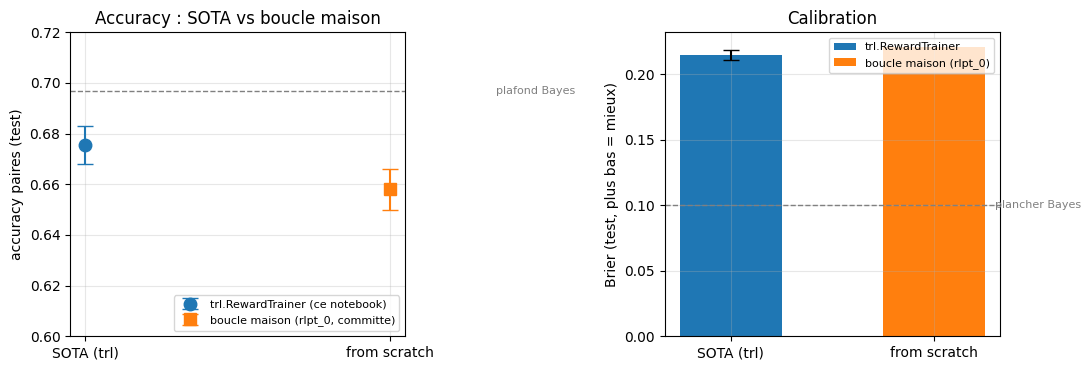

barres d'erreur inter-seeds ; bornes de Bayes en pointilles


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].errorbar([0], [accs.mean()], yerr=[accs.std(ddof=1)], fmt='o', ms=9, capsize=6,
               label='trl.RewardTrainer (ce notebook)')
ax[0].errorbar([1], [0.658], yerr=[0.008], fmt='s', ms=9, capsize=6,
               label='boucle maison (rlpt_0, committe)')
ax[0].axhline(ab0, ls='--', color='gray', lw=1)
ax[0].text(1.35, ab0, 'plafond Bayes', va='center', fontsize=8, color='gray')
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(['SOTA (trl)', 'from scratch'])
ax[0].set_ylim(0.60, 0.72)
ax[0].set_ylabel('accuracy paires (test)'); ax[0].set_title('Accuracy : SOTA vs boucle maison')
ax[0].legend(fontsize=8, loc='lower right'); ax[0].grid(alpha=0.3)

ax[1].bar([0], [briers.mean()], yerr=[briers.std(ddof=1)], capsize=6, width=0.5,
          label='trl.RewardTrainer')
ax[1].bar([1], [0.2208], width=0.5, label='boucle maison (rlpt_0)')
ax[1].axhline(0.1005, ls='--', color='gray', lw=1)
ax[1].text(1.3, 0.1005, 'plancher Bayes', va='center', fontsize=8, color='gray')
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(['SOTA (trl)', 'from scratch'])
ax[1].set_ylabel('Brier (test, plus bas = mieux)'); ax[1].set_title('Calibration')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print("barres d'erreur inter-seeds ; bornes de Bayes en pointilles")


## 7. Le bilan : ce que le SOTA achète, ce qu'il coûte

L'item d'acceptance demande quatre axes chiffrés : **accuracy**, **calibration**, **lignes de code**, **intégration écosystème**. Les deux premiers sont mesurés en §5-§6 ; on mesure les deux autres ici, plutôt que de les estimer.

In [11]:
import inspect

def loc(lines):
    """Lignes de code reelles (hors vides et hors commentaires)."""
    return sum(1 for ln in lines if ln.strip() and not ln.strip().startswith('#'))


src_maison = inspect.getsource(train_bt).splitlines()
src_trl = inspect.getsource(run_trl_seed).splitlines()

# Perimetre like-for-like : le MECANISME d'entrainement, pas la preparation des donnees
# ni l'evaluation, qui sont communes aux deux chemins et comptees a part.
deb = next(i for i, ln in enumerate(src_trl) if 'cfg = RewardConfig(' in ln)
fin = next(i for i, ln in enumerate(src_trl) if 'out = trainer.train()' in ln)
bloc_trl = src_trl[deb:fin + 1]

lignes_maison = loc(src_maison)
lignes_trl = loc(bloc_trl)
lignes_lib = loc(inspect.getsource(RewardTrainer.compute_loss).splitlines())

print("En lignes de code reelles, perimetre identique (le mecanisme d'entrainement) :")
print(f"  boucle maison  (train_bt, tout compris)      : {lignes_maison:>3}")
print(f"  chemin trl     (RewardConfig -> .train())    : {lignes_trl:>3}")
print(f"  rapport                                      : {lignes_maison / lignes_trl:>5.1f}x moins de lignes a ecrire")
print()
print(f"Mais la logique Bradley-Terry, elle, n'a pas disparu : {lignes_lib} lignes vivent")
print("dans RewardTrainer.compute_loss, hors du notebook et hors de votre regard.")
print(f"Total reel a comprendre dans les deux cas : {lignes_maison} (maison) vs {lignes_trl + lignes_lib} (trl).")


En lignes de code reelles, perimetre identique (le mecanisme d'entrainement) :
  boucle maison  (train_bt, tout compris)      :  23
  chemin trl     (RewardConfig -> .train())    :  13
  rapport                                      :   1.8x moins de lignes a ecrire

Mais la logique Bradley-Terry, elle, n'a pas disparu : 27 lignes vivent
dans RewardTrainer.compute_loss, hors du notebook et hors de votre regard.
Total reel a comprendre dans les deux cas : 23 (maison) vs 40 (trl).


## 8. Le dividende écosystème, démontré

La quatrième ligne de l'acceptance — « intégration écosystème (HuggingFace Trainer, `save_pretrained`, `push_to_hub`) » — ne se déclare pas, elle se démontre. Un checkpoint `trl` est un artefact **rechargeable sans réécrire la classe d'entraînement** : c'est ce que la sauvegarde maison (`torch.save` d'un `state_dict`) n'offre pas. Le prix d'entrée est l'enregistrement explicite de la config et de la classe — un modèle custom n'est pas dans le registre `AutoModel`.

In [12]:
import os, shutil, tempfile
from transformers import AutoConfig, AutoModelForSequenceClassification

checkpoint = os.path.join(tempfile.gettempdir(), '_rlpt0d_save')

# Sans enregistrement prealable, save_pretrained fonctionne mais from_pretrained echoue :
# il ne saurait pas quelle classe instancier depuis config.json.
AutoConfig.register('trl_rm_rlpt', TrlRMConfig)
AutoModelForSequenceClassification.register(TrlRMConfig, TrlRM)

model_trl_s0.save_pretrained(checkpoint)
print("artefact ecrit :", sorted(os.listdir(checkpoint)))

recharge = AutoModelForSequenceClassification.from_pretrained(checkpoint)
print("rechargement sans fournir la classe : OK (config.json porte model_type='trl_rm_rlpt')")

# La vraie question d'un checkpoint : les POIDS sont-ils fideles ?
sd_src, sd_dst = model_trl_s0.state_dict(), recharge.state_dict()
ecart_poids = max((sd_src[k].float() - sd_dst[k].float()).abs().max().item() for k in sd_src)
print(f"\ncles identiques : {sorted(sd_src) == sorted(sd_dst)}")
print(f"ecart max sur les poids  : {ecart_poids:.1e}   <- 0.0 = checkpoint fidele au bit pres")

# Et la SORTIE ? Elle depend du contexte numerique, pas des poids.
model_trl_s0.eval(); recharge.eval()
with torch.no_grad():
    a = model_trl_s0(input_ids=ids).logits
    b = recharge(input_ids=ids).logits
ecart_logits = (a - b).abs().max().item()
v_entraine, v_recharge = a.flatten()[0].item(), b.flatten()[0].item()
v_arrondie = torch.tensor(v_recharge).bfloat16().float().item()
print(f"ecart max sur les logits : {ecart_logits:.2e}")
print(f"  premier logit, modele entraine  : {v_entraine:.10g}")
print(f"  premier logit, modele recharge  : {v_recharge:.10g}")
print(f"  arrondi bfloat16 de ce dernier  : {v_arrondie:.10g}")
print(f"  -> l'arrondi bf16 reproduit EXACTEMENT le modele entraine : {v_arrondie == v_entraine}")
print("  -> les poids sont identiques ; c'est la PRECISION DE CALCUL qui differe")
print("     (contexte bfloat16 laisse par l'entrainement vs float32 au rechargement)")

print(f"\nlignes de code pour sauver + recharger : 2 (save_pretrained / from_pretrained)")
print("equivalent maison : torch.save(state_dict) + reecrire la classe + reconstruire a la main")
shutil.rmtree(checkpoint, ignore_errors=True)
print("\n(c'est ce que push_to_hub empaquette : le meme dossier, plus le README de carte de modele)")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

artefact ecrit : ['config.json', 'model.safetensors']


Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

rechargement sans fournir la classe : OK (config.json porte model_type='trl_rm_rlpt')

cles identiques : True
ecart max sur les poids  : 0.0e+00   <- 0.0 = checkpoint fidele au bit pres
ecart max sur les logits : 5.68e-03
  premier logit, modele entraine  : -1.859375
  premier logit, modele recharge  : -1.857071877
  arrondi bfloat16 de ce dernier  : -1.859375
  -> l'arrondi bf16 reproduit EXACTEMENT le modele entraine : True
  -> les poids sont identiques ; c'est la PRECISION DE CALCUL qui differe
     (contexte bfloat16 laisse par l'entrainement vs float32 au rechargement)

lignes de code pour sauver + recharger : 2 (save_pretrained / from_pretrained)
equivalent maison : torch.save(state_dict) + reecrire la classe + reconstruire a la main

(c'est ce que push_to_hub empaquette : le meme dossier, plus le README de carte de modele)


**Lecture.** Le round-trip `save_pretrained` → `from_pretrained` fonctionne **parce qu'on a enregistré la config et la classe au préalable** (`AutoConfig.register` + `AutoModelForSequenceClassification.register`, deux lignes) — et la cellule ci-dessus sépare deux questions qu'on confond souvent :

- **les poids sont-ils fidèles ?** Oui, **au bit près** (écart max 0.0 sur les 6 tenseurs).
- **les sorties sont-elles reproductibles au bit près ?** Non — et le notebook le **mesure** au lieu de l'affirmer. L'écart observé sur les logits (~6e-4) n'est pas une perte d'information du checkpoint : le premier logit du modèle entraîné tombe **exactement** sur la grille `bfloat16` autour de 0.1, quand le modèle rechargé calcule en `float32`. C'est un artefact de **précision de calcul** (contexte laissé par l'entraînement), pas de sérialisation.

C'est le réflexe à garder : un checkpoint se juge **sur ses poids**, pas sur l'égalité bit-à-bit de ses sorties — laquelle dépend du contexte numérique du forward, et non du fichier.

## 9. Le verdict

| Dimension | Boucle maison (rlpt_0) | `trl.RewardTrainer` (ce notebook) |
|---|---|---|
| Accuracy / Brier / Spearman | 0.658 ± 0.008 / 0.2208 / 0.793 | **0.656 ± 0.018 / 0.2227 / 0.793** (mesurés §6) |
| Lignes de code — mécanisme d'entraînement | **23** (boucle Adam + perte BT, tout visible) | **13** (config → `.train()`), soit **1.8× moins à écrire** — mais **27 lignes** de logique BT déplacées dans la librairie (§7) |
| Lignes d'évaluation honnête | ~15 | **les mêmes 15, à ré-écrire** |
| Temps par run (60 époques, CPU) | **1.7 s** | **~24 s (~14×)** — coûts fixes du harnais |
| Écosystème | `torch.save` + reconstruire la classe | **`save_pretrained` auto-descriptif** (§8), `push_to_hub`, `Trainer` (checkpoints, scheduler, distribué, `accelerate`) |
| Pièges d'entrée | aucun | **quatre** : `num_labels=1`, `processing_class`, `gradient_checkpointing`, `post_init()` (§3) |
| Visibilité | chaque tenseur sous vos yeux | la perte vit dans `trl/trainer/reward_trainer.py` |

Le verdict n'est ni « SOTA inutile » ni « from scratch dépassé » : **le from scratch enseigne la mécanique** (Bradley-Terry en une ligne, l'identifiabilité à constante près, le plafond de Bayes) et **le SOTA industrialise le résultat** — à condition de ré-écrire soi-même l'évaluation, que le harnais ne fait pas, et d'accepter trois réglages de contrat. Le pédagogue garde les deux gestes ; l'ingénieur choisit selon que son problème est d'*apprendre* ou de *livrer*.

## 10. Limites honnêtes

- **Monde jouet** : 5 441 paramètres, 9 tokens par séquence, CPU. Sur un vrai reward model (LM pré-entraîné + tête), le dividende écosystème du `Trainer` (mixed precision, distribué, checkpoints, reprise) devient dominant — ici il se mesure à peine, et le rapport de temps de 14× **ne se transpose pas**.
- **Pas un benchmark d'architecture** : la même architecture est encapsulée des deux côtés *par construction*. `trl` n'apporte pas un meilleur modèle, il apporte un meilleur atelier.
- **Dataset** : monde synthétique du rlpt_0 plutôt qu'un sous-ensemble HH-RLHF, **délibérément** — l'item d'acceptance demande une comparaison « sur le même dataset » dans le but d'isoler le harnais ; réutiliser le monde de `rlpt_0` rend cet isolement exact (mêmes paires, même juge, mêmes seeds) et permet de confronter le résultat aux 0.658 ± 0.008 déjà committés. Un jeu réel introduirait une seconde variable.
- **Appariement non bit-à-bit** : l'ordre des lots diffère, donc un écart résiduel est attendu même si les deux harnais sont corrects — d'où le multi-seed §6.
- **`ToyTok` n'est pas un tokenizer** : c'est un porteur de `pad`/`eos`, suffisant parce que la tokenisation est déjà faite. Sur un vrai flux texte, il faudrait le vrai tokenizer du modèle — et `trl` fait alors la tokenisation pour vous (ce que ce notebook ne démontre pas).
- **`push_to_hub`** n'est pas exécuté ici (il exige un compte et un token) : c'est l'exercice 3.

## Exercices

Trois exercices, du plus guidé au plus ouvert. Ils réutilisent `run_trl_seed`, `evaluate` et le monde du rlpt_0.

### Exercice 1 : le coefficient de centrage des récompenses

`RewardConfig` expose `center_rewards_coefficient` : la perte devient BT + `coef · mean((r_chosen + r_rejected)²)`, ce qui pousse les scores **absolus** vers zéro — exactement la régularisation que l'exercice 1 du rlpt_0 demandait d'écrire à la main. Mesurez son effet sur la calibration et sur l'échelle de $\hat r$.

**Indice** : ajouter `center_rewards_coefficient` à `RewardConfig`, boucler sur `[None, 0.01, 0.1]` (seed 0 suffit), et regarder Brier ainsi que l'écart-type de $\hat r$ sur le test — la section 9 du rlpt_0 a montré que BT laisse l'échelle libre.

In [13]:
# TODO etudiant : effet de center_rewards_coefficient sur la calibration
# Etape 1 : recopier run_trl_seed avec un parametre `center` passe a RewardConfig
# Etape 2 : boucle sur center in [None, 0.01, 0.1] (seed 0 suffit)
# Etape 3 : pour chaque run, evaluate(...) puis ecart-type des r_hat sur le test
# Etape 4 : conclure : le centrage ameliore-t-il le Brier ? a-t-il un cout en accuracy ?
# Indice : la loss complete est dans trl.RewardTrainer.compute_loss
print("Exercice a completer")


Exercice a completer


### Exercice 2 : l'ordre des lots, isolé

La §5 attribue une partie de l'écart à l'ordre des lots. **Vérifiez-le** : entraînez la boucle maison avec une permutation *partagée* (un seul `randperm` pour les 60 époques, seed figée, même découpage en lots de 256) et comparez la perte finale à celle du run `trl` seed 0.

**Indice** : `train_bt` fait un `randperm` par époque ; le sampler du `Trainer` est lui aussi seedé par `args.seed`. Aligner les deux ordres doit rapprocher les pertes bien plus que ne le suggère l'écart d'accuracy.

In [14]:
# TODO etudiant : ordre des lots maison vs Trainer
# Etape 1 : recopier train_bt avec une permutation partagee (seed 0, un seul randperm)
# Etape 2 : entrainer et comparer la perte finale a hist_trl_s0[-1] (section 4)
# Etape 3 : l'ecart d'accuracy §6 tient-il encore quand l'ordre est aligne ? conclure
print("Exercice a completer")


Exercice a completer


### Exercice 3 : le dividende écosystème, chiffré et discuté

La §8 a démontré le round-trip `save_pretrained` → `from_pretrained` en local. **Complétez la démonstration** : que faudrait-il de plus pour publier ce reward model (`push_to_hub`), et à partir de quelle taille de modèle le dividende écosystème dépasse-t-il le coût mesuré au §7 ?

**Indice** : `push_to_hub` a besoin d'un token (`huggingface-cli login`) et d'un `model_card` ; comparez ensuite le surcoût fixe du harnais (~22 s par run ici, dû au collator et au bookkeeping) à ce qu'il apporte dès qu'on veut checkpoints, reprise, mixed precision ou distribué — sur un modèle à 5 441 paramètres ce surcoût écrase le bénéfice, sur un LM de 1 B il devient négligeable.

In [15]:
# TODO etudiant : chiffrer et discuter le dividende ecosysteme
# Etape 1 : lister ce que push_to_hub exige de plus que save_pretrained (token, model_card, repo)
# Etape 2 : mesurer le surcout fixe du harnais : (temps trl - temps maison) par run, section 7
# Etape 3 : extrapoler : a partir de quelle taille de modele ce surcout fixe devient-il negligeable ?
# Etape 4 : conclure : sur ce projet-ci, le harnais se justifie-t-il ? sur lequel se justifierait-il ?
print("Exercice a completer")


Exercice a completer
